**NSDC Spring 2025 Machine Learning Project**

*Project Lead:* Philbert Fan

*Project Members:* Kyle He, Daniel Perez, Michelle Ly, Harry Kong, Sophia Knapp, Michelle Lin, Dylan Aubrey, Bernice Wong

For our project, we decided to build our own Machine Learning models from scratch and implement it on a dataset containing Pokemon information. We will predict the pokemon's catch rate from information given such as its Attack, Defense, Type, and other statistics.

We got the dataset from here: https://www.kaggle.com/datasets/alopez247/pokemon

We will build the following Machine Learning models from scratch using only the NumPy package for our project:

* Linear Regression
* K-Nearest Neighbors Regression
* Decision Tree Regression
* Gradient Boosting Regressor
* Random Forest Regressor


Set Up

Including importing all libraries that will be used here

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
path = kagglehub.dataset_download("alopez247/pokemon")
pokemon = pd.read_csv(path + "/pokemon_alopez247.csv", index_col = "Number")
pokemon.head()

100%|██████████| 715k/715k [00:00<00:00, 51.8MB/s]

Extracting files...


,Name,Type_1,Type_2,Total,HP,Attack,Defense,Sp_Atk,Sp_Def,Speed,...,Color,hasGender,Pr_Male,Egg_Group_1,Egg_Group_2,hasMegaEvolution,Height_m,Weight_kg,Catch_Rate,Body_Style
Number,,,,,,,,,,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,...,Green,True,0.875,Monster,Grass,False,0.71,6.9,45,quadruped
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,...,Green,True,0.875,Monster,Grass,False,0.99,13.0,45,quadruped
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,...,Green,True,0.875,Monster,Grass,True,2.01,100.0,45,quadruped
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,...,Red,True,0.875,Monster,Dragon,False,0.61,8.5,45,bipedal_tailed
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,...,Red,True,0.875,Monster,Dragon,False,1.09,19.0,45,bipedal_tailed


Linear Regression

This implementation uses gradient descent. The goal with this algorithm is to learn the parameters that will reduce the MSE. It calculates the gradient which will give the algorithm the direction to move in to find the minimum error.

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        for _ in range(self.n_iters):
            gradients = (2 / n_samples) * X.T @ (X @ self.theta - y)
            self.theta -= self.lr * gradients

    def predict(self, X):
        return X @ self.theta

    def mae(self, X, y):
      y_pred = self.predict(X)
      return np.mean(np.abs(y - y_pred))

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res / ss_tot

K-Nearest Neighbors Regression

In [ ]:
class KNNRegressor:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        preds = []
        for x in X:
            dists = distance.cdist([x], self.X_train)[0]
            neighbors = np.argsort(dists)[:self.k]
            preds.append(np.mean(self.y_train[neighbors]))
        return np.array(preds)

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

    def mae(self, X, y):
        y_pred = self.predict(X)
        return np.mean(np.abs(y - y_pred))


Decision Tree Regression

In [ ]:
class DecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)

    def _mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best_mse = float('inf')
        best_split = None
        n_samples, n_features = X.shape

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for thresh in thresholds:
                left_mask = X[:, feature] <= thresh
                right_mask = X[:, feature] > thresh
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                left_y, right_y = y[left_mask], y[right_mask]
                mse = (len(left_y)*self._mse(left_y) + len(right_y)*self._mse(right_y)) / n_samples
                if mse < best_mse:
                    best_mse = mse
                    best_split = (feature, thresh)
        return best_split

    def _grow_tree(self, X, y, depth=0):
        if len(y) < self.min_samples_split or depth >= self.max_depth or len(set(y)) == 1:
            return np.mean(y)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        left = self._grow_tree(X[left_mask], y[left_mask], depth+1)
        right = self._grow_tree(X[right_mask], y[right_mask], depth+1)

        return (feature, threshold, left, right)

    def _predict_one(self, x, node):
        if not isinstance(node, tuple):
            return node
        feature, threshold, left, right = node
        if x[feature] <= threshold:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

In [ ]:
class Node:
    """Decision tree node class."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Feature index for split
        self.threshold = threshold  # Threshold for numerical feature
        self.left = left            # Left child (<= threshold)
        self.right = right          # Right child (> threshold)
        self.value = value          # Value if leaf node (class label)

    def is_leaf(self):
        """Check if the node is a leaf node."""
        return self.value is not None

In [ ]:
class DecisionTreeRegressor_2:
    """Decision Tree regressor using variance reduction."""

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf = 1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape

        # Stopping criteria
        if (depth == self.max_depth or
                n_samples < self.min_samples_split or
                np.var(y) == 0 or
                n_samples < 2 * self.min_samples_leaf):
            leaf_value = np.mean(y)
            return Node(value=leaf_value)

        # Find best split
        best_feature, best_threshold = self._best_split(X, y)

        if best_feature is None:
            return Node(value=np.mean(y))

        # Split the dataset
        left_idxs = X[:, best_feature] <= best_threshold
        right_idxs = ~left_idxs


        # Check if split satisfies min_samples_leaf
        if sum(left_idxs) < self.min_samples_leaf or sum(right_idxs) < self.min_samples_leaf:
            return Node(value=np.mean(y))

        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)

        return Node(best_feature, best_threshold, left, right)

    def _best_split(self, X, y):
        best_var_reduction = -1
        best_feature, best_threshold = None, None

        for feature_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                var_reduction = self._variance_reduction(X[:, feature_idx], y, threshold)

                if var_reduction > best_var_reduction:
                    best_var_reduction = var_reduction
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def _variance_reduction(self, X_column, y, threshold):
        # calculates how split will reduce variance to determine split quality
        parent_var = np.var(y)

        left_idxs = X_column <= threshold
        right_idxs = ~left_idxs
        n_left, n_right = len(y[left_idxs]), len(y[right_idxs])
        n_total = n_left + n_right

        if n_left == 0 or n_right == 0:
            return 0

        # Calculate weighted child variance
        child_var = (n_left / n_total) * np.var(y[left_idxs]) + \
                    (n_right / n_total) * np.var(y[right_idxs])

        # Variance reduction
        var_reduction = parent_var - child_var
        return var_reduction

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

Gradient Boosting Regressor

In [ ]:
class DecisionStumpRegressor:
    """
    A simple decision stump for regression (one-level decision tree).
    Splits data based on a feature and threshold.
    """
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        m, n = X.shape
        best_mse = float('inf')

        for feature in range(n):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                left_mean = np.mean(y[left_mask])
                right_mean = np.mean(y[right_mask])
                prediction = np.where(left_mask, left_mean, right_mean)
                mse = np.mean((y - prediction) ** 2)
                if mse < best_mse:
                    best_mse = mse
                    self.feature_index = feature
                    self.threshold = threshold
                    self.left_value = left_mean
                    self.right_value = right_mean

    def predict(self, X):
        feature_values = X[:, self.feature_index]
        return np.where(feature_values <= self.threshold, self.left_value, self.right_value)


class GradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.initial_prediction = None

    def fit(self, X, y):
        self.models = []
        self.initial_prediction = np.mean(y)
        y_pred = np.full_like(y, self.initial_prediction, dtype=np.float64)

        for _ in range(self.n_estimators):
            residuals = y - y_pred  # Compute pseudo-residuals
            stump = DecisionStumpRegressor()
            stump.fit(X, residuals)
            update = stump.predict(X)
            y_pred += self.learning_rate * update
            self.models.append(stump)

    def predict(self, X):
        y_pred = np.full((X.shape[0],), self.initial_prediction, dtype=np.float64)
        for stump in self.models:
            y_pred += self.learning_rate * stump.predict(X)
        return y_pred

Random Forest Regressor

In [ ]:
class RandomForestRegressor:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]
            tree = DecisionTreeRegressor_2(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(preds, axis=0)


In [ ]:
# PREPARING DATA USING NUMPY
import numpy as np
import pandas as pd

# Load your DataFrame
df = pokemon  # Change this if your file name differs

# Select numerical columns (basic example, adapt as needed)
numerical_cols = ['Total', 'HP', 'Attack', 'Defense', 'Sp_Atk', 'Sp_Def', 'Speed', 'Height_m', 'Weight_kg']
X = df[numerical_cols].values
y = df['Catch_Rate'].values  # Target column for regression

# Normalize the data (optional but helps with performance)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Split: 80% training, 20% testing
np.random.seed(42)
indices = np.random.permutation(X.shape[0])
split = int(0.8 * X.shape[0])
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]


In [ ]:
# TRAINING RANDOM FOREST REGRESSOR

forest = RandomForestRegressor(n_estimators=20, max_depth=8, min_samples_split=5)
forest.fit(X_train, y_train)


In [ ]:
# EVALUATING PERFORMANCE WITH MSE AND R^2
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - ss_res / ss_total

y_pred = forest.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r_squared(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R Squared:", r2)


Mean Squared Error: 1952.010013305255
R Squared: 0.642722721078085


In [ ]:
# HYPERPARAMETER
best_score = -np.inf
best_params = {}
results = []

for _ in range(10):
    # Randomly sample hyperparameters
    n_estimators = np.random.randint(10, 31)
    max_depth = np.random.randint(3, 16)
    min_samples_split = np.random.randint(2, 11)

    # Train Random Forest
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Evaluate
    r2_score = r_squared(y_test, preds)
    mse_score = mean_squared_error(y_test, preds)

    # Save results
    results.append((n_estimators, max_depth, min_samples_split, r2_score, mse_score))

    if r2_score > best_score:
        best_score = r2_score
        best_params = {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'r2_score': r2_score,
            'mse': mse_score
        }

# Display results
print("Best R²:", best_score)
print("Best Parameters:", best_params)


Best R²: 0.6488871150275035
Best Parameters: {'n_estimators': 30, 'max_depth': 14, 'min_samples_split': 9, 'r2_score': np.float64(0.6488871150275035), 'mse': np.float64(1918.3304052665553)}


In [ ]:
# COMPARING WITH SKLEARN RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train sklearn model using the same feature-engineered data
sk_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=14,
    min_samples_split=9,
    random_state=42
)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

# Evaluate
mse_sk = mean_squared_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

print("Sklearn RandomForest - MSE:", mse_sk)
print("Sklearn RandomForest - R²:", r2_sk)


Sklearn RandomForest - MSE: 1977.2479136878712
Sklearn RandomForest - R²: 0.6381034167133827


MAE (Homemade): 29.89364021602788
MAE (Sklearn): 30.367883609388027


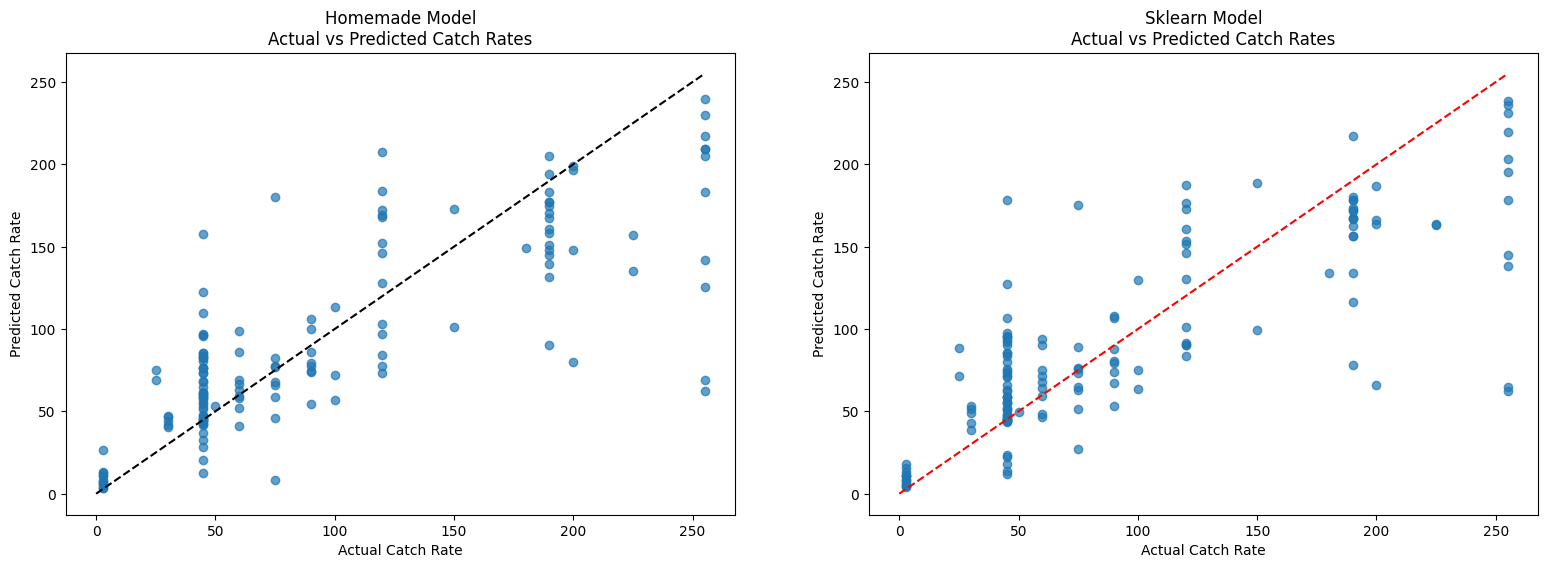

In [ ]:
# VISUALIZING THE 2 DIFFERENT MODELS

import matplotlib.pyplot as plt

# Actual vs predicted values
actual = y_test
homemade_pred = forest.predict(X_test)        # from-scratch model
sklearn_pred = y_pred_sk                      # sklearn model

fig, axs = plt.subplots(1, 2, figsize=(19, 6))

# Homemade Model
axs[0].scatter(actual, homemade_pred, alpha=0.7)
axs[0].plot([0, max(actual)], [0, max(actual)], 'k--')  # Ideal line
axs[0].set_title("Homemade Model\nActual vs Predicted Catch Rates")
axs[0].set_xlabel("Actual Catch Rate")
axs[0].set_ylabel("Predicted Catch Rate")

# Sklearn Model
axs[1].scatter(actual, sklearn_pred, alpha=0.7)
axs[1].plot([0, max(actual)], [0, max(actual)], 'r--')  # Ideal line
axs[1].set_title("Sklearn Model\nActual vs Predicted Catch Rates")
axs[1].set_xlabel("Actual Catch Rate")
axs[1].set_ylabel("Predicted Catch Rate")

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

mae = mean_absolute_error(y_test, y_pred)
print("MAE (Homemade):", mae)

mae_sk = mean_absolute_error(y_test, y_pred_sk)
print("MAE (Sklearn):", mae_sk)



Data Exploration



In [ ]:
print(pokemon.head())
print(pokemon.shape)
print(pokemon.columns)
print(pokemon.Type_1.value_counts())
print(pokemon.Type_2.value_counts())
print(pokemon.Body_Style.value_counts())
pokemon[pokemon.Type_1 == "Water"].Type_2.value_counts()
pokemon[pokemon.Type_2 == "Flying"].Type_1.value_counts()
# look into NAs or see if there's any values that seem like errors?

              Name Type_1  Type_2  Total  HP  Attack  Defense  Sp_Atk  Sp_Def  \
Number                                                                          
1        Bulbasaur  Grass  Poison    318  45      49       49      65      65   
2          Ivysaur  Grass  Poison    405  60      62       63      80      80   
3         Venusaur  Grass  Poison    525  80      82       83     100     100   
4       Charmander   Fire     NaN    309  39      52       43      60      50   
5       Charmeleon   Fire     NaN    405  58      64       58      80      65   

        Speed  ...  Color  hasGender Pr_Male  Egg_Group_1  Egg_Group_2  \
Number         ...                                                       
1          45  ...  Green       True   0.875      Monster        Grass   
2          60  ...  Green       True   0.875      Monster        Grass   
3          80  ...  Green       True   0.875      Monster        Grass   
4          65  ...    Red       True   0.875      Monster     

,count
Type_1,
Normal,23
Bug,13
Water,7
Psychic,6
Fire,5
Dark,5
Grass,4
Dragon,4
Poison,3


Data Cleaning and Feature Engineering (if necessary)

In [ ]:
max(pokemon['Sp_Def'])

230

In [ ]:
# make categories variables longform
pokemon_no_name = pokemon.drop('Name', axis = 1)
#pokemon_no_name.columns
long_pokemon = pd.get_dummies(pokemon_no_name)
long_pokemon.head()

,Total,HP,Attack,Defense,Sp_Atk,Sp_Def,Speed,Generation,isLegendary,hasGender,...,Body_Style_head_base,Body_Style_head_legs,Body_Style_head_only,Body_Style_insectoid,Body_Style_multiple_bodies,Body_Style_quadruped,Body_Style_serpentine_body,Body_Style_several_limbs,Body_Style_two_wings,Body_Style_with_fins
Number,,,,,,,,,,,,,,,,,,,,,
1,318,45,49,49,65,65,45,1,False,True,...,False,False,False,False,False,True,False,False,False,False
2,405,60,62,63,80,80,60,1,False,True,...,False,False,False,False,False,True,False,False,False,False
3,525,80,82,83,100,100,80,1,False,True,...,False,False,False,False,False,True,False,False,False,False
4,309,39,52,43,60,50,65,1,False,True,...,False,False,False,False,False,False,False,False,False,False
5,405,58,64,58,80,65,80,1,False,True,...,False,False,False,False,False,False,False,False,False,False


Data Visualization

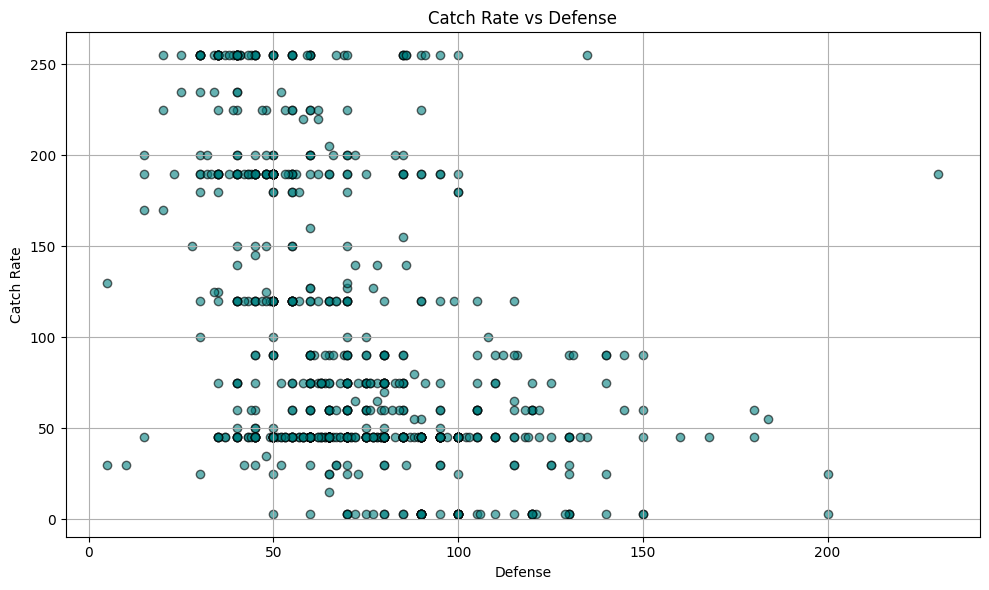

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(pokemon["Defense"], pokemon["Catch_Rate"], alpha=0.6, color='teal', edgecolors='k')
plt.title("Catch Rate vs Defense")
plt.xlabel("Defense")
plt.ylabel("Catch Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


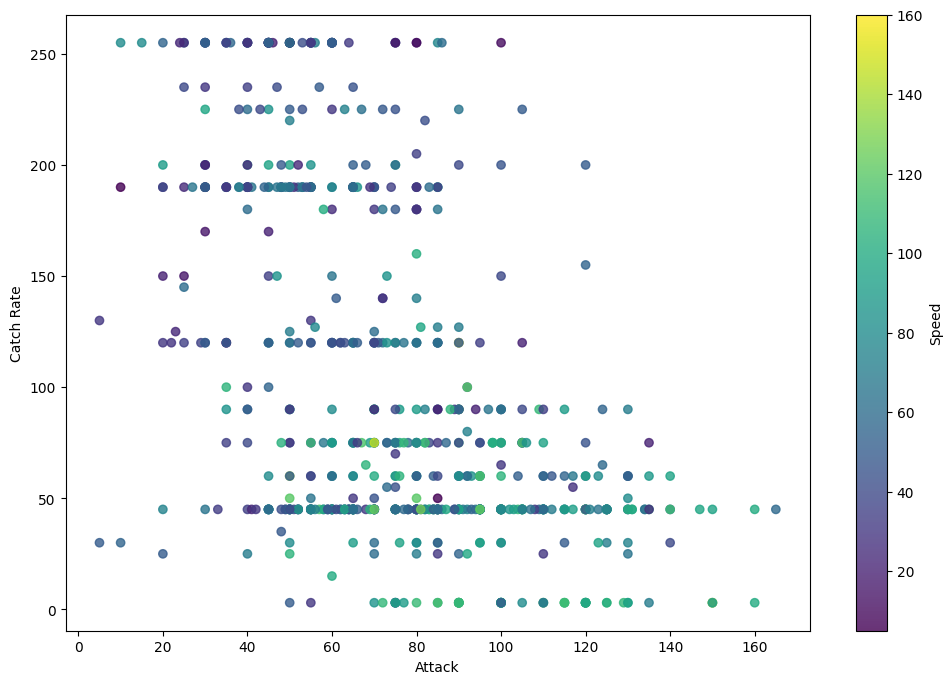

In [ ]:
import matplotlib.pyplot as plt
# plt.hist(pokemon[pokemon.Type_1 == "Bug"].Catch_Rate, color = 'purple', alpha = 0.5, edgecolor = "white")
# plt.hist(pokemon[pokemon.Type_1 == "Water"].Catch_Rate, color = 'blue', alpha = 0.5, edgecolor = "white")
# plt.hist(pokemon[pokemon.Type_1 == "Normal"].Catch_Rate, color = 'gray', alpha = 0.5, edgecolor = "white")
# plt.hist(pokemon[pokemon.Type_1 == "Grass"].Catch_Rate, color = 'green', alpha = 0.4, edgecolor = "white")
# plt.show()

#make a better visualization lol
plt.figure(figsize = (12, 8))
plt.scatter(long_pokemon['Attack'], long_pokemon['Catch_Rate'], c = long_pokemon['Speed'],  alpha = 0.8)
plt.xlabel("Attack")
plt.ylabel("Catch Rate")
plt.colorbar(label = "Speed")
plt.show()

               Total    Attack        HP   Defense    Sp_Atk    Sp_Def  \
Total       1.000000  0.704164  0.642628  0.605831  0.723737  0.706501   
Attack      0.704164  1.000000  0.431680  0.433233  0.335205  0.207211   
HP          0.642628  0.431680  1.000000  0.228834  0.368640  0.376006   
Defense     0.605831  0.433233  0.228834  1.000000  0.202519  0.483986   
Sp_Atk      0.723737  0.335205  0.368640  0.202519  1.000000  0.492861   
Sp_Def      0.706501  0.207211  0.376006  0.483986  0.492861  1.000000   
Speed       0.548890  0.335013  0.170031 -0.008663  0.443106  0.233487   
Generation  0.092868  0.093857  0.071545  0.068409  0.069689  0.055421   
Height_m    0.526813  0.408590  0.442872  0.354205  0.330579  0.313196   
Weight_kg   0.535966  0.469395  0.431320  0.476983  0.285048  0.328645   
Catch_Rate -0.738280 -0.525106 -0.478725 -0.436558 -0.539114 -0.513014   

               Speed  Generation  Height_m  Weight_kg  Catch_Rate  
Total       0.548890    0.092868  0.526813 

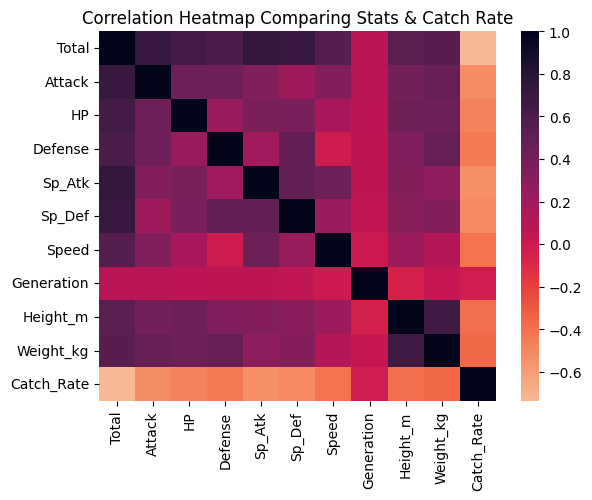

In [ ]:
# Correlation Heatmap for Stats
import seaborn as sns
pokemon_corr = pokemon[['Total', 'Attack', 'HP', 'Defense', 'Sp_Atk', 'Sp_Def', 'Speed', 'Generation', 'Height_m', 'Weight_kg', 'Catch_Rate']]
print(pokemon_corr.corr())

sns.heatmap(pokemon_corr.corr(), center=0, cmap = 'rocket_r')
plt.title("Correlation Heatmap Comparing Stats & Catch Rate")
plt.show()

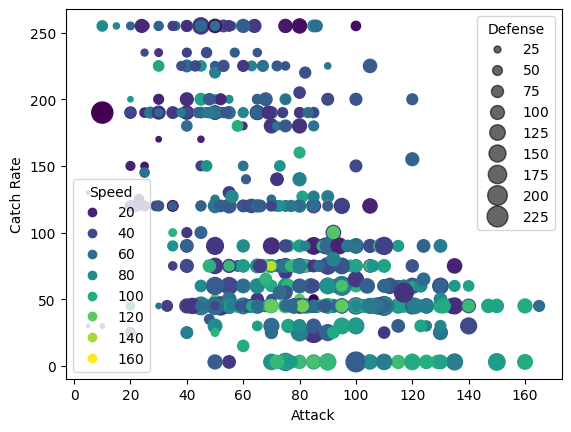

In [ ]:
fig, ax = plt.subplots()
scatter = ax.scatter(long_pokemon['Attack'], long_pokemon['Catch_Rate'], c = long_pokemon['Speed'], s = long_pokemon['Defense'])

legend1 = ax.legend(*scatter.legend_elements(),
                    loc="lower left", title="Speed")
ax.add_artist(legend1)

# produce a legend with a cross-section of sizes from the scatter
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend2 = ax.legend(handles, labels, loc="upper right", title="Defense")

plt.xlabel("Attack")
plt.ylabel("Catch Rate")
plt.show()

In [ ]:
print(list(long_pokemon.columns))

['Total', 'HP', 'Attack', 'Defense', 'Sp_Atk', 'Sp_Def', 'Speed', 'Generation', 'isLegendary', 'hasGender', 'Pr_Male', 'hasMegaEvolution', 'Height_m', 'Weight_kg', 'Catch_Rate', 'Type_1_Bug', 'Type_1_Dark', 'Type_1_Dragon', 'Type_1_Electric', 'Type_1_Fairy', 'Type_1_Fighting', 'Type_1_Fire', 'Type_1_Flying', 'Type_1_Ghost', 'Type_1_Grass', 'Type_1_Ground', 'Type_1_Ice', 'Type_1_Normal', 'Type_1_Poison', 'Type_1_Psychic', 'Type_1_Rock', 'Type_1_Steel', 'Type_1_Water', 'Type_2_Bug', 'Type_2_Dark', 'Type_2_Dragon', 'Type_2_Electric', 'Type_2_Fairy', 'Type_2_Fighting', 'Type_2_Fire', 'Type_2_Flying', 'Type_2_Ghost', 'Type_2_Grass', 'Type_2_Ground', 'Type_2_Ice', 'Type_2_Normal', 'Type_2_Poison', 'Type_2_Psychic', 'Type_2_Rock', 'Type_2_Steel', 'Type_2_Water', 'Color_Black', 'Color_Blue', 'Color_Brown', 'Color_Green', 'Color_Grey', 'Color_Pink', 'Color_Purple', 'Color_Red', 'Color_White', 'Color_Yellow', 'Egg_Group_1_Amorphous', 'Egg_Group_1_Bug', 'Egg_Group_1_Ditto', 'Egg_Group_1_Dragon', 

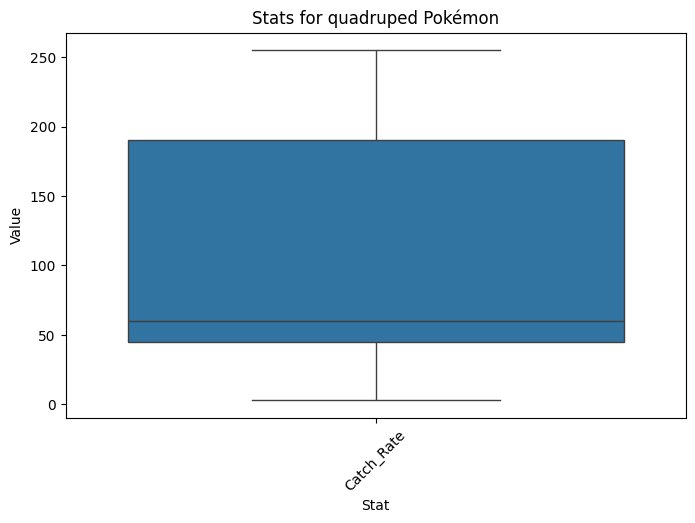

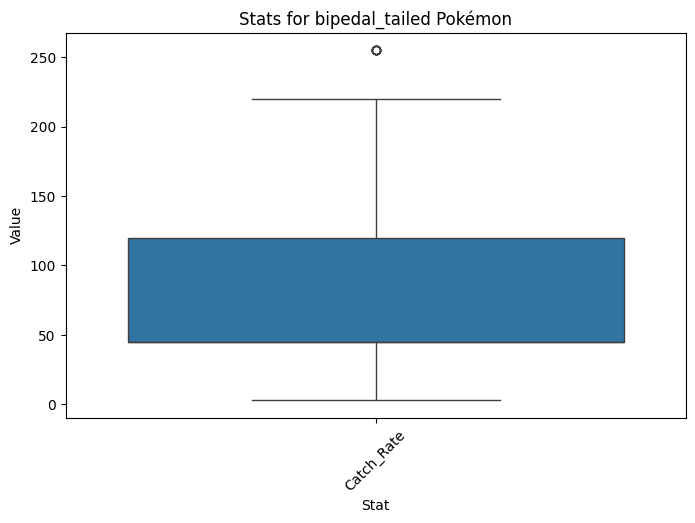

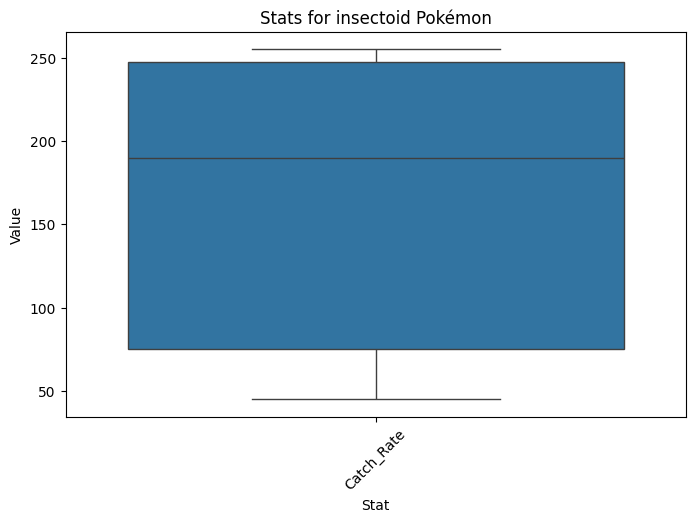

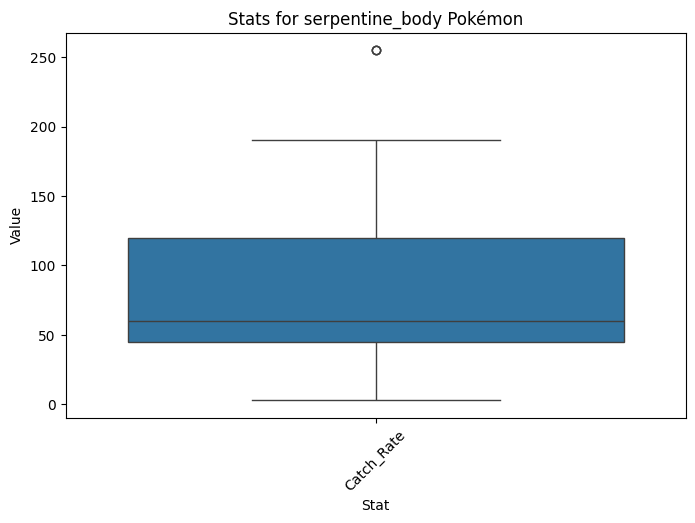

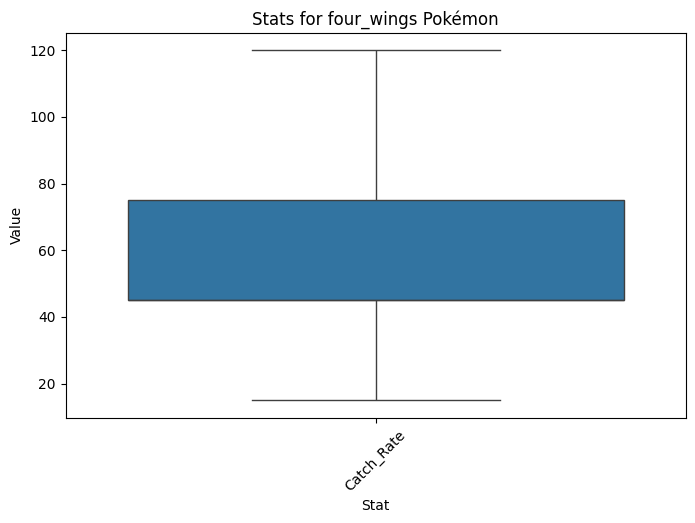

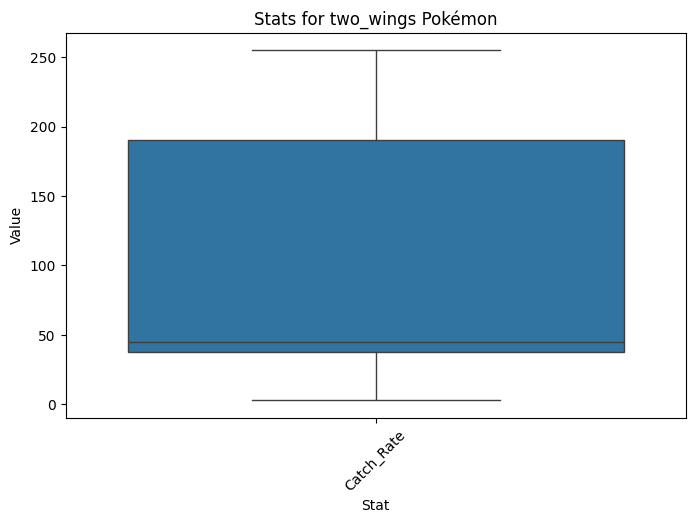

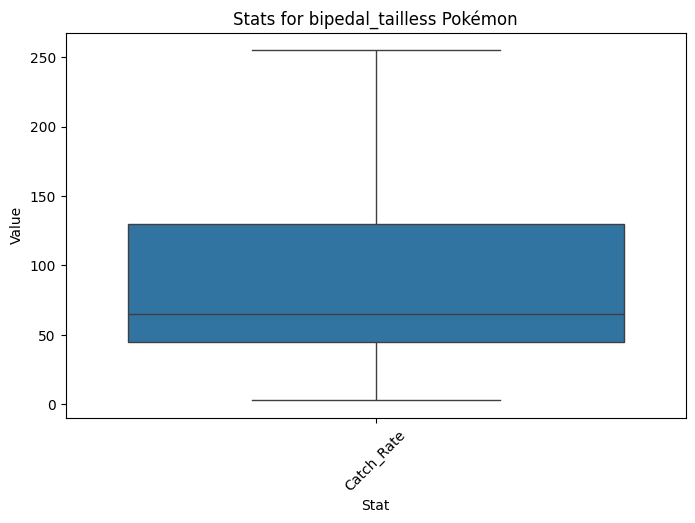

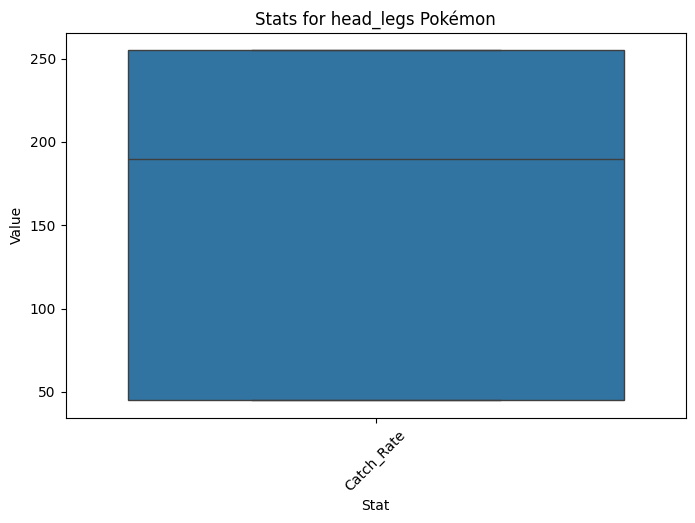

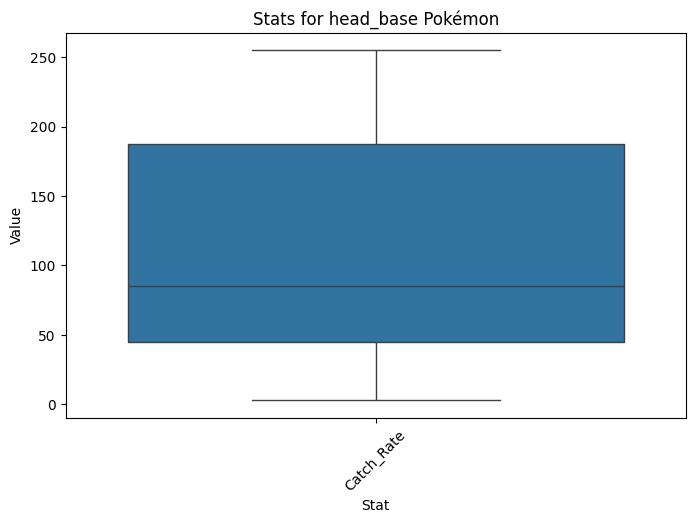

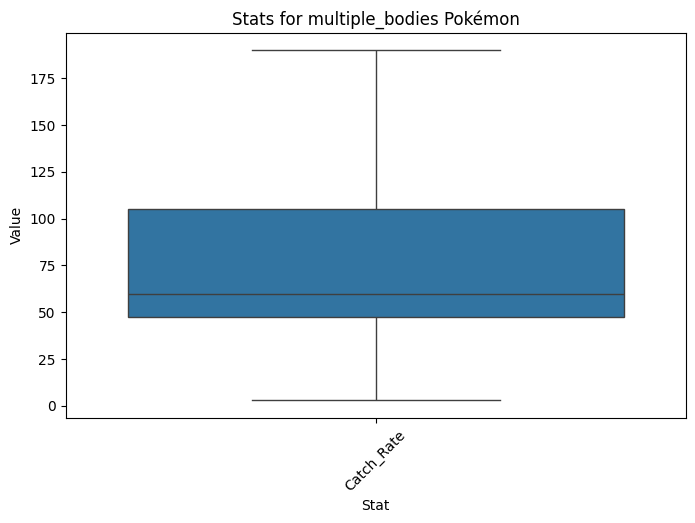

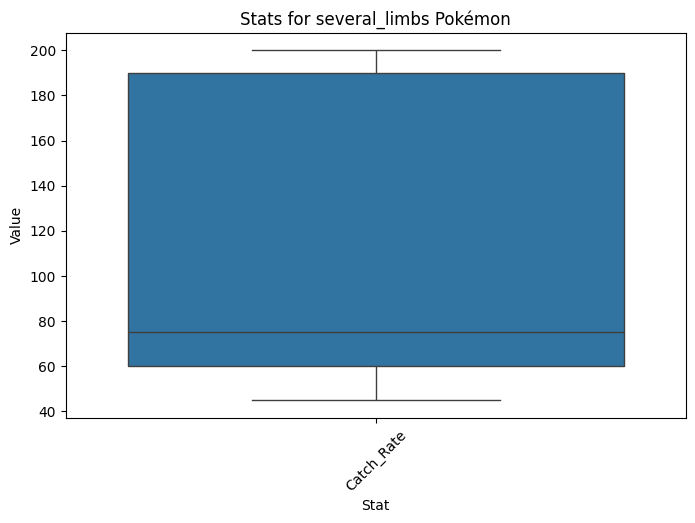

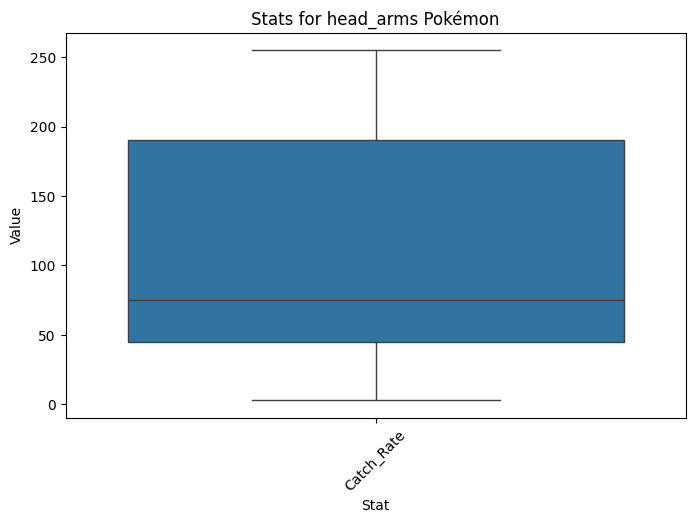

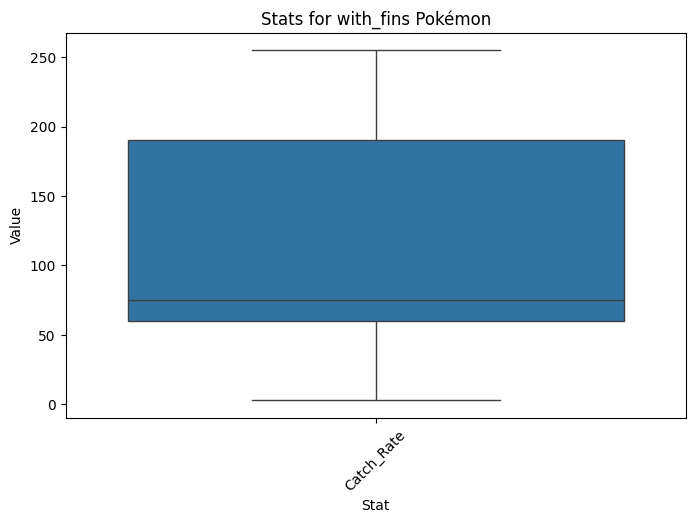

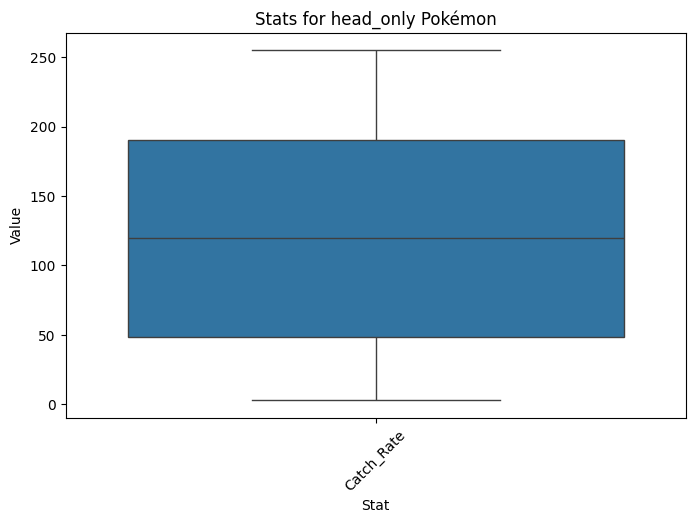

In [ ]:
import seaborn as sns

stat_cols = ["Catch_Rate"]
body_style_cols = [
    "Body_Style_bipedal_tailed", "Body_Style_bipedal_tailless", "Body_Style_four_wings",
    "Body_Style_head_arms", "Body_Style_head_base", "Body_Style_head_legs", "Body_Style_head_only",
    "Body_Style_insectoid", "Body_Style_multiple_bodies", "Body_Style_quadruped",
    "Body_Style_serpentine_body", "Body_Style_several_limbs", "Body_Style_two_wings", "Body_Style_with_fins"
]

long_pokemon["Body_Style"] = long_pokemon[body_style_cols].idxmax(axis=1).str.replace("Body_Style_", "")

long_pokemon_plot = long_pokemon.melt(id_vars=["Body_Style"], value_vars=stat_cols, var_name="Stat", value_name="Value")

for body_style in long_pokemon_plot["Body_Style"].unique():
    plt.figure(figsize=(8, 5))
    subset = long_pokemon_plot[long_pokemon_plot["Body_Style"] == body_style]

    sns.boxplot(x="Stat", y="Value", data=subset)
    plt.title(f"Stats for {body_style} Pokémon")
    plt.xticks(rotation=45)
    plt.show()

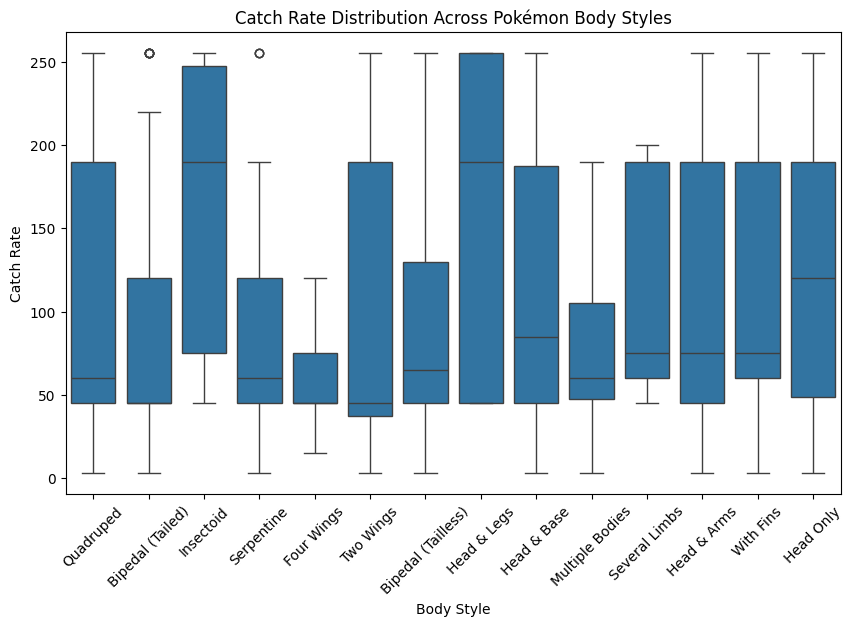

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

stat_cols = ["Catch_Rate"]
body_style_cols = [
    "Body_Style_bipedal_tailed", "Body_Style_bipedal_tailless", "Body_Style_four_wings",
    "Body_Style_head_arms", "Body_Style_head_base", "Body_Style_head_legs", "Body_Style_head_only",
    "Body_Style_insectoid", "Body_Style_multiple_bodies", "Body_Style_quadruped",
    "Body_Style_serpentine_body", "Body_Style_several_limbs", "Body_Style_two_wings", "Body_Style_with_fins"
]

long_pokemon["Body_Style"] = long_pokemon[body_style_cols].idxmax(axis=1).str.replace("Body_Style_", "")

long_pokemon_plot = long_pokemon.melt(id_vars=["Body_Style"], value_vars=stat_cols, var_name="Stat", value_name="Value")

body_style_labels = {
    "bipedal_tailed": "Bipedal (Tailed)", "bipedal_tailless": "Bipedal (Tailless)",
    "four_wings": "Four Wings", "head_arms": "Head & Arms", "head_base": "Head & Base",
    "head_legs": "Head & Legs", "head_only": "Head Only", "insectoid": "Insectoid",
    "multiple_bodies": "Multiple Bodies", "quadruped": "Quadruped",
    "serpentine_body": "Serpentine", "several_limbs": "Several Limbs",
    "two_wings": "Two Wings", "with_fins": "With Fins"
}

long_pokemon_plot["Body_Style"] = long_pokemon_plot["Body_Style"].replace(body_style_labels)

for stat in stat_cols:
    plt.figure(figsize=(10, 6))
    subset = long_pokemon_plot[long_pokemon_plot["Stat"] == stat]

    sns.boxplot(x="Body_Style", y="Value", data=subset)
    plt.title(f"Catch Rate Distribution Across Pokémon Body Styles")
    plt.xticks(rotation=45)
    plt.ylabel("Catch Rate")
    plt.xlabel("Body Style")

    plt.show()

Training Models

Split the data into training and test sets.

In [ ]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_size = int(len(X) * test_size)
    train_idx, test_idx = indices[test_size:], indices[:test_size]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [ ]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

In [ ]:
# Select features and target
features = ['Total', 'HP', 'Attack', 'Defense', 'Sp_Atk', 'Sp_Def', 'Speed',
                'Height_m', 'Weight_kg', 'Generation', 'isLegendary']
target = 'Catch_Rate'

pokemon['isLegendary'] = pokemon['isLegendary'].astype(int)

 # Handle missing values if any (this dataset appears clean)
X = pokemon[features].values
y = pokemon[target].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

Training our implemented Linear Regression:

In [ ]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std
X_scaled_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
X_train, X_test, y_train, y_test = train_test_split(X_scaled_b, y)
model = LinearRegression(learning_rate=0.01, n_iters=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score on test set: {r2:.4f}")

Mean Absolute Error (MAE): 40.7434
R² Score on test set: 0.4912


In [ ]:
# Try different learning rates and iteration counts
learning_rates = [0.001, 0.005, 0.01, 0.05]
iterations = [500, 1000, 2000]
best_r2 = -np.inf
best_params = None
for lr in learning_rates:
    for n_iter in iterations:
        model = LinearRegression(learning_rate=lr, n_iters=n_iter)
        model.fit(X_train, y_train)
        r2 = model.score(X_test, y_test)
        mae = model.mae(X_test, y_test)
        print(f"LR: {lr}, Iters: {n_iter} → R²: {r2:.4f}, MAE: {mae:.2f}")
        if r2 > best_r2:
            best_r2 = r2
            best_params = (lr, n_iter)
# Retrain on best params
lr_best, n_iter_best = best_params
final_model = LinearRegression(learning_rate=lr_best, n_iters=n_iter_best)
final_model.fit(X_train, y_train)
# Predict and evaluate
y_pred = final_model.predict(X_test)
r2_final = final_model.score(X_test, y_test)
mae_final = final_model.mae(X_test, y_test)
print(f"\nBest Model → LR: {lr_best}, Iters: {n_iter_best}")
print(f"Final R² Score: {r2_final:.4f}")
print(f"Final Mean Absolute Error: {mae_final:.2f}")

LR: 0.001, Iters: 500 → R²: 0.2250, MAE: 54.41
LR: 0.001, Iters: 1000 → R²: 0.4479, MAE: 43.10
LR: 0.001, Iters: 2000 → R²: 0.4890, MAE: 40.83
LR: 0.005, Iters: 500 → R²: 0.4904, MAE: 40.77
LR: 0.005, Iters: 1000 → R²: 0.4911, MAE: 40.75
LR: 0.005, Iters: 2000 → R²: 0.4912, MAE: 40.74
LR: 0.01, Iters: 500 → R²: 0.4911, MAE: 40.75
LR: 0.01, Iters: 1000 → R²: 0.4912, MAE: 40.74
LR: 0.01, Iters: 2000 → R²: 0.4912, MAE: 40.74
LR: 0.05, Iters: 500 → R²: 0.4912, MAE: 40.74
LR: 0.05, Iters: 1000 → R²: 0.4912, MAE: 40.74
LR: 0.05, Iters: 2000 → R²: 0.4912, MAE: 40.74

Best Model → LR: 0.05, Iters: 2000
Final R² Score: 0.4912
Final Mean Absolute Error: 40.74


Now the sklearn Linear Regression:

In [ ]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Train scikit-learn Linear Regression model
sk_model = SklearnLinearRegression()
sk_model.fit(X_train, y_train)

# Predict
y_pred_sk = sk_model.predict(X_test)

# Evaluate
r2_sk = r2_score(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

# Your model
y_pred_custom = model.predict(X_test)
r2_custom = model.score(X_test, y_test)
mae_custom = np.mean(np.abs(y_test - y_pred_custom))

print("Comparison of Linear Regression Models")
print("--------------------------------------")
print(f"NumPy Implementation:")
print(f"  R² Score: {r2_custom:.4f}")
print(f"  MAE     : {mae_custom:.4f}")
print()
print(f"Scikit-Learn Implementation:")
print(f"  R² Score: {r2_sk:.4f}")
print(f"  MAE     : {mae_sk:.4f}")

Comparison of Linear Regression Models
--------------------------------------
NumPy Implementation:
  R² Score: 0.4912
  MAE     : 40.7432

Scikit-Learn Implementation:
  R² Score: 0.4912
  MAE     : 40.7432


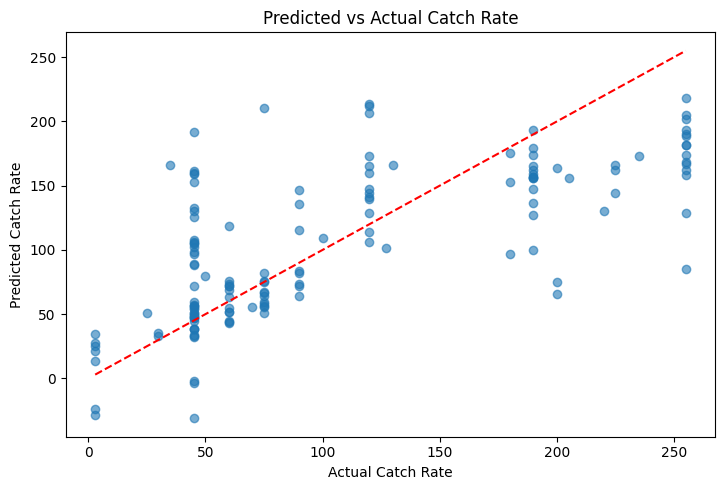

In [ ]:
plt.figure(figsize=(14, 5))
# Custom model
plt.subplot(1, 2, 1)
plt.scatter(y_test, final_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicted vs Actual Catch Rate')
plt.xlabel('Actual Catch Rate')
plt.ylabel('Predicted Catch Rate')

plt.tight_layout()
plt.show()


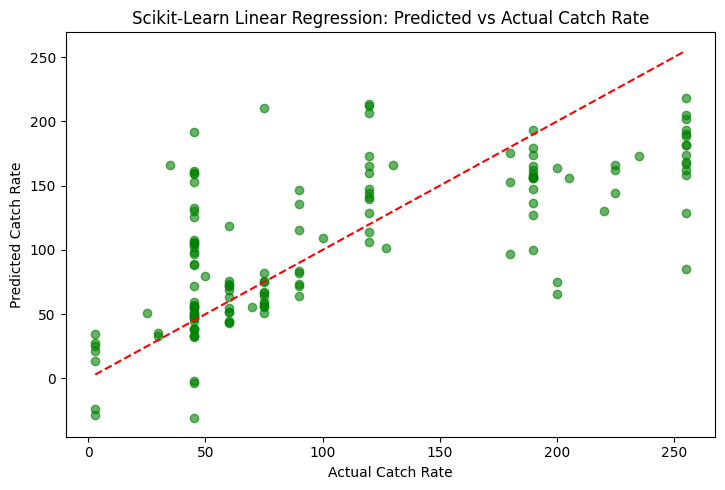

In [ ]:
# Sklearn model
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sk, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Scikit-Learn Linear Regression: Predicted vs Actual Catch Rate')
plt.xlabel('Actual Catch Rate')
plt.ylabel('Predicted Catch Rate')

plt.tight_layout()
plt.show()

Training KNN Regressor

In [ ]:
# Hyperparameter tuning for best k
best_r2 = -np.inf
best_k = None
results = []

for k in range(1, 21):
    model = KNNRegressor(k=k)
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    mae = model.mae(X_test, y_test)
    results.append((k, r2, mae))
    if r2 > best_r2:
        best_r2 = r2
        best_k = k

# Final training and evaluation with best k
final_knn = KNNRegressor(k=best_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)

print(f"Best k: {best_k}")
print(f"Final R² Score: {final_knn.score(X_test, y_test):.4f}")
print(f"Final MAE: {final_knn.mae(X_test, y_test):.4f}")


NameError: name 'distance' is not defined

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Use the same best_k as in your homemade model
sk_knn = KNeighborsRegressor(n_neighbors=best_k)
sk_knn.fit(X_train, y_train)

# Predict
y_pred_sk = sk_knn.predict(X_test)

# Evaluate
r2_sk = r2_score(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

# Homemade results
r2_homemade = final_knn.score(X_test, y_test)
mae_homemade = final_knn.mae(X_test, y_test)

# Print comparison
print("Comparison of Homemade vs Scikit-Learn KNN")
print("------------------------------------------")
print(f"Best k: {best_k}")
print(f"Homemade KNN → R²: {r2_homemade:.4f}, MAE: {mae_homemade:.4f}")
print(f"Scikit-Learn KNN → R²: {r2_sk:.4f}, MAE: {mae_sk:.4f}")



In [ ]:
# Predict with both models
y_pred_homemade = final_knn.predict(X_test)
y_pred_sk = sk_knn.predict(X_test)
# Scatter plots
plt.figure(figsize=(14, 5))
# Homemade KNN
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_homemade, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Predicted vs Actual Catch Rate")
plt.xlabel("Actual Catch Rate")
plt.ylabel("Predicted Catch Rate")
plt.tight_layout()
plt.show()


In [ ]:
# Scikit-learn KNN
plt.figure(figsize = (20, 5))
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sk, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Scikit-Learn KNN: Predicted vs Actual Catch Rate")
plt.xlabel("Actual Catch Rate")
plt.ylabel("Predicted Catch Rate")

Training Decision Tree Regressor:

In [ ]:
from itertools import product

def grid_search(X_train_full, y_train_full, test_size=0.2):
    # Split training data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=test_size,
        random_state=42
    )

    max_depths = [3, 4, 5, 6, None]
    min_samples_splits = [2, 5, 10, 20]
    min_samples_leaves = [1, 2, 5, 10]

    best_mae = float('inf')
    best_params = {}

    for max_depth, min_samples_split, min_samples_leaf in product(
        max_depths, min_samples_splits, min_samples_leaves
    ):
        tree = DecisionTreeRegressor_2(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf
        )
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_val)
        mae = mean_absolute_error(y_val, y_pred)
        r_squared_val = r_squared(y_val, y_pred)

        if mae < best_mae:
            best_mae = mae
            best_params = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf
            }
    return best_params, best_mae



In [ ]:
# try it on a model:

# 1. split into train, test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)

# 2. Run grid search on TRAIN_FULL
best_params, val_mae = grid_search(X_train_full, y_train_full)

# 3. Final evaluation on untouched TEST SET
final_tree = DecisionTreeRegressor_2(**best_params)
final_tree.fit(X_train_full, y_train_full)  # Train on ALL training data
y_pred_final = final_tree.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred_final)

print(f"Validation MAE during tuning: {val_mae:.2f}")
print(f"True test MAE: {test_mae:.2f}")

##Evaluating model performance and selecting best models

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Perfect prediction line
plt.xlabel('Actual Catch Rate')
plt.ylabel('Predicted Catch Rate')
plt.title('Actual vs Predicted Catch Rates')
plt.grid(True)
plt.show()